# "How many artifacts to make Spire of Industry worth playing"

https://www.reddit.com/r/EDH/comments/1tagjyc/how_many_artifacts_to_make_spire_of_industry/?ref=share&ref_source=link

"How many artifacts do you guys think would need to be in a deck to make it worth it to include [[Spire of Industry]] in the deck? I’m wondering if there’s a good sweet spot for how many because I currently have a deck with 19 artifacts in it and I’m debating on if I should actually include it."

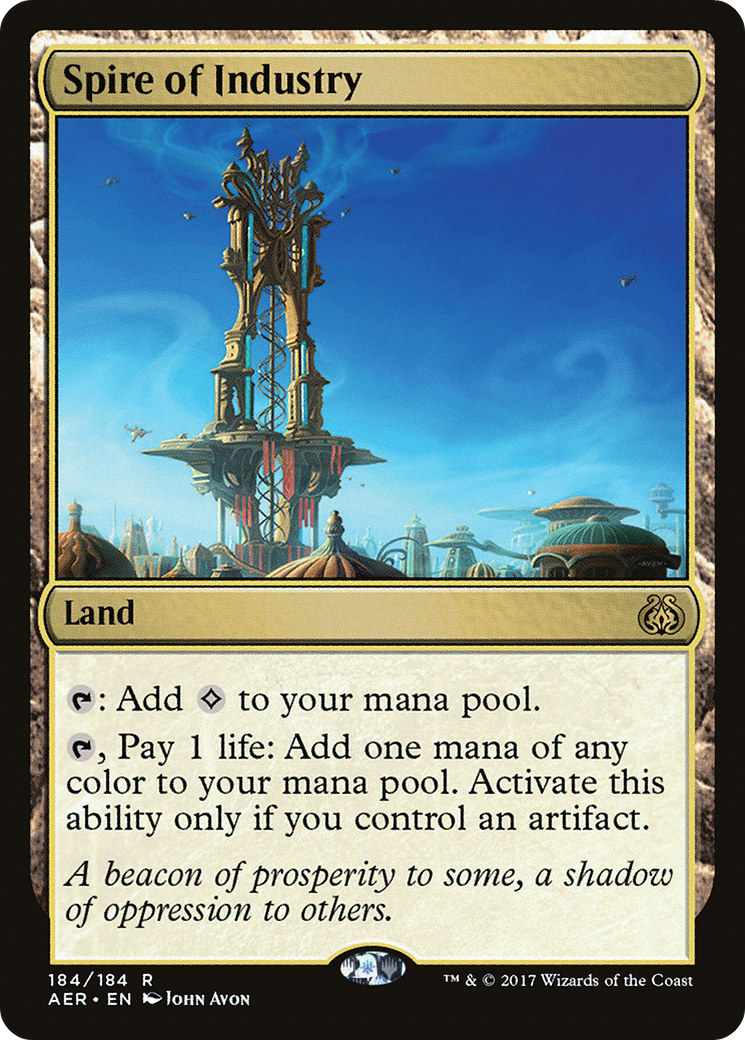

## The Method
1. Download bulk card data from Scryfall.
2. Find artifacts.
3. Select decks that include Spire of Industry.
4. Calculate average count of artifacts.

In [9]:
import json
import random

In [10]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from scryfall import Scryfall

### 1. Download bulk card data from Scryfall.

In [11]:
scryfall_client = Scryfall()

In [12]:
oracle_cards = scryfall_client.bulk_data("oracle_cards")
print(f"Cards: {len(oracle_cards)}")

Cards: 38626


### 2. Find artifacts.

In [ ]:
artifacts = []
for card in oracle_cards:
    if ("Artifact" in card["type_line"]
        and "Creature" not in card["type_line"]
        and "Land" not in card["type_line"]):
        artifacts.append(card)
print(f"Artifacts: {len(artifacts)}")

artifacts = [c["name"] for c in artifacts if c["legalities"]["commander"] == "legal"]
print(f"Commander-legal artifacts: {len(artifacts)}")

Artifacts: 2601
Commander-legal artifacts: 2307


In [14]:
random.sample(artifacts, 5)

['Cursed Recording',
 "Paleontologist's Pick-Axe // Dinosaur Headdress",
 'Obelisk of Urd',
 'Font of Mythos',
 'Cosmos Elixir']

### 3. Select decks that include Spire of Industry.

In [ ]:
folder = project_root / "decks"

if not folder.exists():
    raise FileNotFoundError(f"Deck folder not found: {folder}")

spire_of_industry_decks = []
valid_decks_count = 0

for commander_file in folder.iterdir():
    with open(commander_file, "r", encoding="utf-8") as f:
        commander_decks = json.load(f)
    if len(commander_decks) == 0:
        continue

    for deck in commander_decks:
        for card in deck["deck"]:
            if "Spire of Industry" in card:
                spire_of_industry_decks.append(deck)
                valid_decks_count += 1
                break

print(f"Decks that include Spire of Industry: {valid_decks_count}")

Decks that include Spire of Industry: 277296


### 4. Calculate average count of artifacts.

In [ ]:
artifact_card_count = 0

for deck in spire_of_industry_decks:
    for card in deck["deck"]:
        card_parts = card.split(" ")
        card_name = " ".join(card_parts[1:])
        card_quantity = int(card_parts[0])

        if card_name in artifacts:
            artifact_card_count += card_quantity

average = artifact_card_count / valid_decks_count
print(f"Average number of artifacts in decks that include Spire of Industry: {average:.2f}")

Average number of artifacts in decks that include Spire of Industry: 18.40
